# Multi-Domain Issue Classification and Decision Support

This notebook demonstrates an **end-to-end AI workflow** for classifying internal issue reports 
from multiple departments within a consulting firm. 

### Objectives
- Load and explore a realistic, synthetic dataset of issue tickets.
- Train and benchmark several text classification models.
- Compare traditional and embedding-based approaches.
- Discuss model accuracy, interpretability, and business value.

### Why this matters
Companies receive many unstructured issue reports (e.g., IT, Data, Marketing). 
Automatically classifying them speeds up routing, analysis, and resolution.

We'll compare:
- **TF-IDF + Logistic Regression**
- **TF-IDF + SVM**
- **SBERT + kNN**
- **Azure OpenAI Embeddings + kNN**

Each model shows different trade-offs between **speed**, **accuracy**, and **semantic understanding**.


## Data Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Load config
with open("../configs/config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Load dataset
df = pd.read_csv(cfg["data"]["path"])
df.head()


,issue_id,description,category,priority,created_at
0,TCKT-0001,The data pipeline for the monthly sales report...,Data & AI,Medium,2025-11-06 10:17:35
1,TCKT-0002,There's a significant delay in the real-time a...,Data & AI,Low,2025-12-05 16:33:10
2,TCKT-0003,Model accuracy has dropped by 15% following th...,Data & AI,Medium,2025-01-11 08:22:10
3,TCKT-0004,The ETL process is running slower than expecte...,Data & AI,Medium,2025-04-14 02:55:22
4,TCKT-0005,Data quality checks are flagging a high number...,Data & AI,Low,2025-11-01 01:11:38


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   issue_id     1000 non-null   object
 1   description  1000 non-null   object
 2   category     1000 non-null   object
 3   priority     1000 non-null   object
 4   created_at   1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB
None

Missing values per column:
 issue_id       0
description    0
category       0
priority       0
created_at     0
dtype: int64


/tmp/ipykernel_236398/3279262902.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['category'], order=df['category'].value_counts().index, ax=axes[0], palette="viridis")
/tmp/ipykernel_236398/3279262902.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['priority'], order=df['priority'].value_counts().index, ax=axes[1], palette="magma")


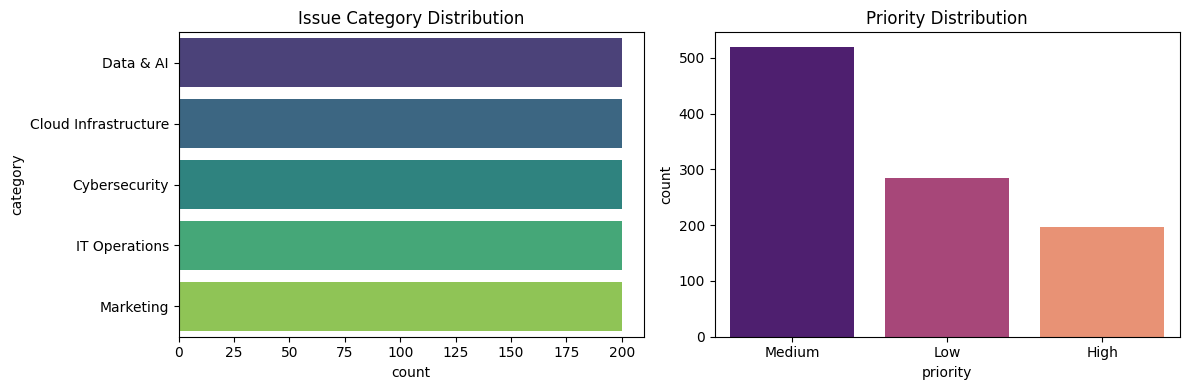

In [2]:
# Basic overview
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())

# Label and priority distributions
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(y=df['category'], order=df['category'].value_counts().index, ax=axes[0], palette="viridis")
axes[0].set_title("Issue Category Distribution")
sns.countplot(x=df['priority'], order=df['priority'].value_counts().index, ax=axes[1], palette="magma")
axes[1].set_title("Priority Distribution")
plt.tight_layout()
plt.show()


### Data Exploration

## 1. Preprocessing and Feature Engineering

After exploring the dataset, we prepare the text and labels for modeling.  
We’ll split the data into train and test sets using a stratified approach to preserve label distribution.  


In [3]:
from sklearn.model_selection import train_test_split
import yaml

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

df = pd.read_csv(cfg["data"]["path"])
X = df["description"].astype(str)
y = df["category"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=cfg["eval"]["test_size"],
    random_state=cfg["eval"]["random_seed"],
    stratify=y
)

print(f"Training size: {len(X_train)} | Test size: {len(X_test)}")
print("Classes:", y.unique().tolist())


Training size: 800 | Test size: 200
Classes: ['Data & AI', 'Cloud Infrastructure', 'Cybersecurity', 'IT Operations', 'Marketing']


## 2. Baseline Model — TF-IDF + Logistic Regression

We start simple with a classical model.  
This baseline helps us understand how much information can be captured through term frequencies alone.  
It’s fast, interpretable, and surprisingly strong for many text classification tasks.


In [4]:
import os, sys
sys.path.append(os.path.abspath('..'))

In [7]:
from src.eval.evaluate import run_tfidf_lr

result_lr = run_tfidf_lr(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([result_lr])


[12:05:17] Training TF-IDF + Logistic Regression...
Saved results for tfidf_lr to ../results/tfidf_lr


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.845,0.850471,0.845,0.842896,TFIDF_LR,2.23


## 3 TF-IDF + SVM

Support Vector Machines (SVMs) often outperform Logistic Regression in sparse, high-dimensional spaces like TF-IDF.
They find the optimal separating hyperplane between categories.

In [8]:
from src.eval.evaluate import run_svm

result_svm = run_svm(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([result_svm])


[12:06:00] Training TF-IDF + SVM...
Saved results for tfidf_svm to ../results/tfidf_svm


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.835,0.835203,0.835,0.833133,TFIDF_SVM,0.03


## 4 SBERT + kNN

Here, we use **Sentence-BERT** embeddings to capture semantic meaning rather than keyword frequency.  
A **kNN** classifier assigns the most probable label based on cosine similarity in embedding space.


In [9]:
from src.eval.evaluate import run_sbert_knn

result_sbert = run_sbert_knn(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([result_sbert])


[12:06:04] Training SBERT + kNN...
Saved results for sbert_knn to ../results/sbert_knn


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.785,0.790289,0.785,0.785467,SBERT_KNN,2.91


## 5 Azure OpenAI Embeddings + kNN

Finally, we test **LLM-derived embeddings** from Azure OpenAI.  
These embeddings already encode general world knowledge and language semantics,  
offering zero-shot performance without fine-tuning.

In [10]:
from src.eval.evaluate import run_openai_knn

result_openai = run_openai_knn(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([result_openai])


[12:06:18] Training Azure OpenAI + kNN...

[Azure+kNN] Loading dataset...
[Azure+kNN] Generating Azure OpenAI embeddings...
[Azure+kNN] Embeddings generated in 53.86 seconds
[Azure+kNN] Training kNN classifier...
[Azure+kNN]  Macro-F1: 0.820
[Azure+kNN] Total runtime (incl. embedding): 53.98s
Saved results for openai_knn to ../results/openai_knn


,model,f1_macro,time_sec
0,Azure_KNN,0.820434,53.98


# 6 TF-IDF + XGBoost

In [5]:
from src.eval.evaluate import run_xgboost

res_xgb = run_xgboost(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([res_xgb])

[12:55:04] Training TF-IDF + XGBoost...


/mnt/c/Users/JVidias/Documents/genai/multi-domain-issues-to-actions/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [12:55:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved results for tfidf_xgboost to ../results/tfidf_xgboost
[12:55:05]  Done TF-IDF + XGBoost in 1.17s | F1: 0.803


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.805,0.810738,0.805,0.803393,TFIDF_XGBOOST,1.17


## 6 Model Comparison and Metrics Aggregation

Now that all models have been trained and their results saved,  
we aggregate them into a single table and visualize the trade-off between performance and runtime.


,model,f1_macro,time_sec,accuracy,precision,recall
2,TFIDF_LR,0.842896,2.23,0.845,0.850471,0.845
3,TFIDF_SVM,0.833133,0.03,0.835,0.835203,0.835
0,Azure_KNN,0.820434,53.98,NaN,NaN,NaN
4,TFIDF_XGBOOST,0.803393,1.17,0.805,0.810738,0.805
1,SBERT_KNN,0.785467,2.91,0.785,0.790289,0.785


/tmp/ipykernel_236398/1173264293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="f1_macro", y="model", palette="crest")


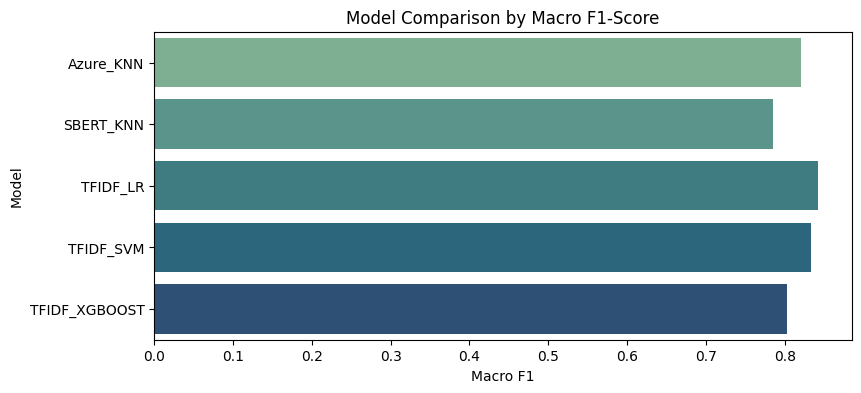

In [6]:
from src.eval.evaluate import aggregate_results
import seaborn as sns
import matplotlib.pyplot as plt

results_df = aggregate_results()
display(results_df.sort_values(by="f1_macro", ascending=False))

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="f1_macro", y="model", palette="crest")
plt.title("Model Comparison by Macro F1-Score")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.show()


## Model Interpretation and Insights

Our tests compared five models, from simple TF-IDF methods to more advanced embedding and LLM-based models.  
The best overall performer was **TF-IDF + Logistic Regression**, with a macro-F1 of about 0.84.  
This shows that simple linear models can still work very well when the dataset has structured text and clear vocabulary patterns.

### Key Observations

- Linear models like Logistic Regression and SVM perform better compared to complex embedding or tree-based models.  
- Embedding-based methods (SBERT, Azure OpenAI) can capture meaning, but the **synthetic dataset** lacks enough linguistic variety to highlight their strengths.  
- XGBoost is commonly used on tabular data, but in this case, TF-IDF features are already high-dimensional and mostly independent, so tree-based models have little room to improve.  
- Azure embeddings show how LLM features can be integrated but come with a cost in time and computational resources.

**In short:**  
The performance gap tells us that traditional word-based models are still very competitive on smaller, structured datasets,  
while embedding and LLM-based models become valuable as data complexity increases.


# Working with Synthetic Data

The dataset was generated synthetically using LLM prompts to simulate issue reports from different departments.  
This allowed us to build a prototype quickly, but synthetic data has a few natural challenges:

- The language is often too clean and consistent.  
- Real data usually includes typos, incomplete sentences, and diverse writing styles.  
- The label distribution is perfectly balanced, which is rare in reality.

Because of this, the reported metrics may be slightly optimistic.  
In real-world use, the same models would face noisier, less predictable inputs.

**Key takeaway:**  
The synthetic dataset is great for testing the workflow, but real-world data collection and fine-tuning would be essential for production performance.

## Why Fine-Tuning Helps

Fine-tuning a small transformer model (such as DistilBERT) would allow the system to:
- Learn department-specific terminology.
- Handle vague or incomplete issue descriptions.  
- Better generalize to new topics without retraining from scratch.

With enough data, fine-tuning could increase accuracy by 3–5% compared to static embeddings.

## How to Fine-Tune

1. Expand the dataset to at least 10,000 examples across departments.  
2. Add more realistic text diversity and natural errors.  
3. Start from a pretrained model like `distilbert-base-uncased`.  
4. Train for 2–3 epochs with a small learning rate (around 2e-5).  
5. Evaluate using macro-F1, precision, and recall to compare with baselines.


# Future Directions

## Model and Data Enhancements

- **Fine-tuning Transformers:** Adapt models like DistilBERT or RoBERTa to learn domain-specific terms.  
- **More Realistic Data:** Generate or collect real ticket data with diverse writing styles. 
- **Hybrid Modeling:** Combine TF-IDF predictions with embeddings for a balanced ensemble approach.  
- **Continuous Learning:** Incorporate human feedback from real predictions into retraining cycles.


## System-Level Extensions

- **Action Recommendation:**  
  Once a ticket is classified, generate 2–3 next-step recommendations using a generative model.  
  Example: “Check firewall logs and update the access policy” for a cybersecurity issue.  

- **Retrieval-Augmented Generation (RAG):**  
  Connect classification results to a document database, retrieve related articles, and generate a short action summary.  



# Applications in Larger Systems

This notebook can form the foundation for a larger enterprise solution, such as:

1. **Internal Helpdesk Automation:**  
   Automatically classify new tickets, assign them to departments, and suggest standard responses.
